In [1]:
import subprocess
subprocess.run(['pip', 'install', 'mlflow', '-q'])

import os, json, time, warnings, logging
from pathlib import Path
from datetime import datetime
from collections import defaultdict
warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import joblib
import mlflow

# ── Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from tqdm.auto import tqdm

# ── ML / Clustering
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.pipeline import Pipeline

# ── Stats
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import f_oneway, kruskal

# ── Reproducibility
SEED = 42
np.random.seed(SEED)

print('=' * 55)
print('  nb-05 — Customer Behavior Clustering')
print('=' * 55)
print(f'  Research Q : What behavioral patterns predict')
print(f'               purchase sentiment?')
print(f'  Algorithms : K-Means | DBSCAN | Agglomerative')
print(f'               | Gaussian Mixture')
print(f'  Features   : Behavior + Sentiment + Platform')
print(f'  Started    : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 16.6 MB/s eta 0:00:00


2026-04-25 10:46:25,229 | INFO | NumExpr defaulting to 4 threads.


  nb-05 — Customer Behavior Clustering
  Research Q : What behavioral patterns predict
               purchase sentiment?
  Algorithms : K-Means | DBSCAN | Agglomerative
               | Gaussian Mixture
  Features   : Behavior + Sentiment + Platform
  Started    : 2026-04-25 10:46:32


In [2]:
ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    NB02_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/Textprocessing&feature')
    NB03_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/notebook3')
    NB04_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/nb-04-BILSTM')
    DATA_DIR = NB02_OUT / 'data' / 'processed'
    WORK_DIR = Path('/kaggle/working')
else:
    DATA_DIR = Path('../data/processed')
    WORK_DIR = Path('..')

OUT_DIR = WORK_DIR / 'clustering'
FIG_DIR = WORK_DIR / 'outputs' / 'figures'
LOG_DIR = WORK_DIR / 'mlflow_runs'

for d in [OUT_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'random_state'   : SEED,
    'n_clusters_range': list(range(2, 11)),  # test 2→10 clusters
    'final_k'        : 5,                    # updated after elbow
    'min_samples'    : 50,                   # DBSCAN min_samples
    'eps_range'      : [0.3, 0.5, 0.8, 1.0, 1.5],
    'experiment_name': '03_Customer_Behavior_Clustering',
    'run_name'       : f'clustering-v1-{datetime.now().strftime("%Y%m%d_%H%M")}',
}

print('📁 Checking input files:')
files_to_check = [
    (DATA_DIR / 'features_sample.csv', 'features_sample'),
    (DATA_DIR / 'features_full.csv',   'features_full'),
]
for path, name in files_to_check:
    exists = path.exists()
    mb = path.stat().st_size / 1e6 if exists else 0
    print(f'   {"✅" if exists else "❌"} {name:<30} {mb:.1f} MB')

print(f'\n✅ Output dir : {OUT_DIR}')
print(f'   Config     : {CFG["n_clusters_range"]} clusters to test')

📁 Checking input files:
   ❌ features_sample                0.0 MB
   ❌ features_full                  0.0 MB

✅ Output dir : /kaggle/working/clustering
   Config     : [2, 3, 4, 5, 6, 7, 8, 9, 10] clusters to test


In [3]:
import os

def explore(path, indent=0):
    try:
        for item in os.listdir(path):
            full = os.path.join(path, item)
            if os.path.isdir(full):
                print('  ' * indent + f'📁 {item}/')
                explore(full, indent + 1)
            else:
                mb = os.path.getsize(full) / 1e6
                print('  ' * indent + f'└── {item}  ({mb:.1f} MB)')
    except:
        pass

explore('/kaggle/input')

📁 notebooks/
  📁 bennjimatakwa/
    📁 notebook3/
    📁 textprocessing-feature/
      └── __results__.html  (0.4 MB)
      📁 models/
        └── scaler_standard.pkl  (0.0 MB)
        └── feature_registry.json  (0.0 MB)
        └── encoding_maps.json  (0.0 MB)
        └── le_sentiment.pkl  (0.0 MB)
        └── scaler_minmax.pkl  (0.0 MB)
        └── le_platform.pkl  (0.0 MB)
        └── class_weights.pkl  (0.0 MB)
      └── __notebook__.ipynb  (0.0 MB)
      └── __output__.json  (0.0 MB)
      📁 data/
        📁 processed/
          └── val.csv  (6.4 MB)
          └── features_sample.csv  (65.5 MB)
          └── train.csv  (46.8 MB)
          └── test.csv  (12.3 MB)
      └── custom.css  (0.0 MB)
    📁 nb-04-bilstm/
      📁 mlflow_runs/
        📁 966490607344820746/
          └── meta.yaml  (0.0 MB)
          📁 models/
            📁 m-33bc8d63d8394251a2705ef9aa8eaa38/
              └── meta.yaml  (0.0 MB)
              📁 params/
                └── lr  (0.0 MB)
                └── warmup_

In [4]:
ON_KAGGLE = os.path.exists('/kaggle/input')

if ON_KAGGLE:
    # ── nb-02 output (behavior features)
    NB02_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/textprocessing-feature')
    # ── nb-04 output (bilstm predictions + features_with_bilstm)
    NB04_OUT = Path('/kaggle/input/notebooks/bennjimatakwa/nb-04-bilstm')

    DATA_DIR    = NB02_OUT / 'data' / 'processed'
    DATA_DIR_04 = NB04_OUT / 'data' / 'processed'
    MODEL_IN    = NB02_OUT / 'models'
    WORK_DIR    = Path('/kaggle/working')
else:
    DATA_DIR    = Path('../data/processed')
    DATA_DIR_04 = Path('../data/processed')
    MODEL_IN    = Path('../models')
    WORK_DIR    = Path('..')

OUT_DIR = WORK_DIR / 'clustering'
FIG_DIR = WORK_DIR / 'outputs' / 'figures'
LOG_DIR = WORK_DIR / 'mlflow_runs'

for d in [OUT_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'random_state'    : SEED,
    'n_clusters_range': list(range(2, 11)),
    'final_k'         : 5,
    'min_samples'     : 50,
    'eps_range'       : [0.3, 0.5, 0.8, 1.0, 1.5],
    'experiment_name' : '03_Customer_Behavior_Clustering',
    'run_name'        : f'clustering-v1-{datetime.now().strftime("%Y%m%d_%H%M")}',
}

# ── Check all input files
print('📁 Checking input files:')
files_to_check = [
    (DATA_DIR    / 'features_sample.csv',    'features_sample   (nb-02)'),
    (DATA_DIR    / 'train.csv',              'train             (nb-02)'),
    (DATA_DIR_04 / 'features_with_bilstm.csv','features_with_bilstm (nb-04)'),
    (MODEL_IN    / 'class_weights.pkl',      'class_weights     (nb-02)'),
]
for path, name in files_to_check:
    exists = path.exists()
    mb = path.stat().st_size / 1e6 if exists else 0
    print(f'   {"✅" if exists else "❌"} {name:<40} {mb:.1f} MB')

print(f'\n✅ Output dir : {OUT_DIR}')

📁 Checking input files:
   ✅ features_sample   (nb-02)                65.5 MB
   ✅ train             (nb-02)                46.8 MB
   ✅ features_with_bilstm (nb-04)             69.0 MB
   ✅ class_weights     (nb-02)                0.0 MB

✅ Output dir : /kaggle/working/clustering


In [5]:
log.info('Loading data...')

# ── Load features_sample from nb-02
df = pd.read_csv(DATA_DIR / 'features_sample.csv')
print(f'✅ features_sample loaded: {df.shape}')

# ── Load bilstm predictions from nb-04 and merge
bilstm_cols = ['bilstm_sentiment', 'bilstm_confidence',
               'bilstm_prob_neg', 'bilstm_prob_neu', 'bilstm_prob_pos']

if (DATA_DIR_04 / 'features_with_bilstm.csv').exists():
    df_bilstm = pd.read_csv(
        DATA_DIR_04 / 'features_with_bilstm.csv',
        usecols=bilstm_cols,
        low_memory=False
    )
    for col in bilstm_cols:
        if col in df_bilstm.columns:
            df[col] = df_bilstm[col].values[:len(df)]
    print(f'✅ BiLSTM predictions added: {bilstm_cols}')
else:
    print(f'⚠️  features_with_bilstm.csv not found')

# ── Behavior features (from nb-02)
BEHAVIOR_FEATURES = [
    'word_count', 'char_per_word', 'unique_word_ratio',
    'exclamation_count', 'question_count', 'caps_ratio',
    'recency_weight', 'influence_weight', 'importance',
    'has_reply', 'is_auto_reply', 'log_response_time',
    'complaint_depth', 'positive_brevity',
    'frustration_score', 'engagement_quality',
    'review_year', 'review_month', 'review_dayofweek',
    'review_hour', 'is_weekend'
]

# ── BiLSTM sentiment probability features
BILSTM_FEATURES = [
    col for col in ['bilstm_prob_neg', 'bilstm_prob_neu',
                    'bilstm_prob_pos', 'bilstm_confidence']
    if col in df.columns
]

# ── Platform-level aggregated features
log.info('Engineering platform-level features...')
platform_agg = df.groupby('appName').agg(
    avg_score         = ('score', 'mean'),
    std_score         = ('score', 'std'),
    avg_word_count    = ('word_count', 'mean'),
    avg_thumbs        = ('thumbsUpCount', 'mean'),
    reply_rate        = ('has_reply', 'mean'),
    avg_response_time = ('log_response_time', 'mean'),
    pct_negative      = ('sentiment', lambda x: (x=='negative').mean()),
    pct_neutral       = ('sentiment', lambda x: (x=='neutral').mean()),
    pct_positive      = ('sentiment', lambda x: (x=='positive').mean()),
    avg_frustration   = ('frustration_score', 'mean'),
    avg_engagement    = ('engagement_quality', 'mean'),
    avg_recency       = ('recency_weight', 'mean'),
    review_count      = ('score', 'count')
).reset_index()

df = df.merge(
    platform_agg.add_prefix('plt_').rename(
        columns={'plt_appName': 'appName'}),
    on='appName', how='left'
)

PLATFORM_FEATURES = [c for c in df.columns if c.startswith('plt_')]

# ── All features combined
ALL_FEATURES = BEHAVIOR_FEATURES + BILSTM_FEATURES + PLATFORM_FEATURES
ALL_FEATURES = [f for f in ALL_FEATURES if f in df.columns]

print(f'\n✅ Feature groups:')
print(f'   Behavior features : {len(BEHAVIOR_FEATURES)}')
print(f'   BiLSTM features   : {len(BILSTM_FEATURES)}')
print(f'   Platform features : {len(PLATFORM_FEATURES)}')
print(f'   Total features    : {len(ALL_FEATURES)}')

# ── Drop rows with NaN
df_clean = df[ALL_FEATURES + ['appName','sentiment','score','sentiment_id']].dropna()
print(f'   Rows after dropna : {len(df_clean):,}')

2026-04-25 10:46:32,738 | INFO | Loading data...


✅ features_sample loaded: (99999, 43)


2026-04-25 10:46:36,699 | INFO | Engineering platform-level features...


✅ BiLSTM predictions added: ['bilstm_sentiment', 'bilstm_confidence', 'bilstm_prob_neg', 'bilstm_prob_neu', 'bilstm_prob_pos']

✅ Feature groups:
   Behavior features : 21
   BiLSTM features   : 4
   Platform features : 13
   Total features    : 38
   Rows after dropna : 99,999


In [6]:
# ── Extract feature matrix
X           = df_clean[ALL_FEATURES].values.astype(float)
y_sentiment = df_clean['sentiment_id'].values
y_platform  = df_clean['appName'].values

# ── Scale features
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Save scaler
joblib.dump(scaler, OUT_DIR / 'clustering_scaler.pkl')

print(f'✅ Feature matrix ready:')
print(f'   Shape     : {X_scaled.shape}')
print(f'   Mean      : {X_scaled.mean():.4f} (should be ~0)')
print(f'   Std       : {X_scaled.std():.4f} (should be ~1)')

# ── PCA for visualization (2D + 3D)
log.info('Running PCA...')
pca_2d = PCA(n_components=2, random_state=SEED)
pca_3d = PCA(n_components=3, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)
X_pca3 = pca_3d.fit_transform(X_scaled)

print(f'\n   PCA 2D variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.1f}%')
print(f'   PCA 3D variance explained: {pca_3d.explained_variance_ratio_.sum()*100:.1f}%')

# ── Feature importance from PCA
feat_importance = pd.DataFrame({
    'feature'   : ALL_FEATURES,
    'pc1_weight': np.abs(pca_2d.components_[0]),
    'pc2_weight': np.abs(pca_2d.components_[1]),
}).assign(importance=lambda x: x['pc1_weight'] + x['pc2_weight'])

feat_importance = feat_importance.sort_values('importance', ascending=False)

print(f'\n   Top 10 features by PCA importance:')
print(feat_importance[['feature','importance']].head(10).to_string(index=False))

2026-04-25 10:46:37,025 | INFO | Running PCA...


✅ Feature matrix ready:
   Shape     : (99999, 38)
   Mean      : 0.0000 (should be ~0)
   Std       : 1.0000 (should be ~1)

   PCA 2D variance explained: 28.1%
   PCA 3D variance explained: 35.1%

   Top 10 features by PCA importance:
            feature  importance
   plt_review_count    0.518634
     plt_reply_rate    0.478883
    bilstm_prob_pos    0.439977
          has_reply    0.431451
         word_count    0.427936
   positive_brevity    0.418808
     plt_avg_thumbs    0.404256
plt_avg_frustration    0.388937
      plt_avg_score    0.382178
   plt_pct_positive    0.376838


# Elbow Method & Optimal K

2026-04-25 10:46:37,167 | INFO | Running elbow method...


Testing K values:   0%|          | 0/9 [00:00<?, ?it/s]

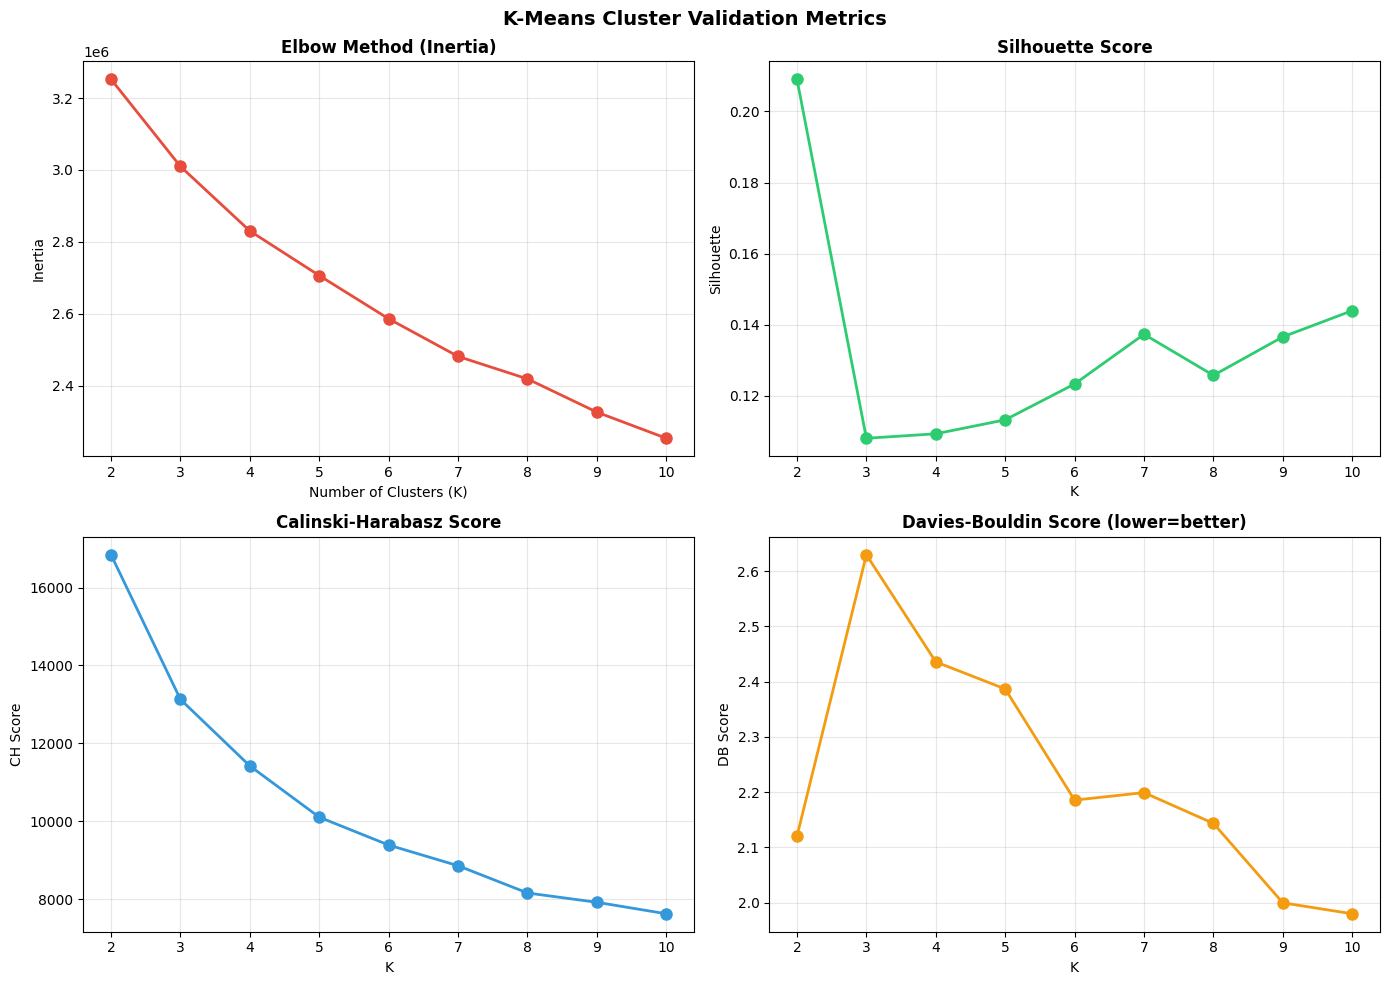

 K Inertia Silhouette CH Score DB Score
 2 3252215     0.2091    16842   2.1203
 3 3009684     0.1081    13128   2.6294
 4 2830219     0.1094    11421   2.4355
 5 2706099     0.1133    10105   2.3866
 6 2585846     0.1234     9390   2.1854
 7 2481119     0.1374     8858   2.1990
 8 2418531     0.1258     8159   2.1433
 9 2326044     0.1366     7920   1.9995
10 2253371     0.1440     7625   1.9797

✅ Best K by Silhouette : 2
   Best K by DB Score   : 10

   → Using K=5 (update CFG["final_k"] if needed)


In [7]:
log.info('Running elbow method...')

inertias      = []
silhouettes   = []
ch_scores     = []
db_scores     = []
k_range       = CFG['n_clusters_range']

for k in tqdm(k_range, desc='Testing K values'):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10, max_iter=300)
    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=SEED))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels))
    db_scores.append(davies_bouldin_score(X_scaled, labels))

# ── Plot all metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Means Cluster Validation Metrics', fontweight='bold', fontsize=14)

axes[0,0].plot(k_range, inertias, 'o-', color='#e74c3c', linewidth=2, markersize=8)
axes[0,0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0,0].set_xlabel('Number of Clusters (K)')
axes[0,0].set_ylabel('Inertia')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(k_range, silhouettes, 'o-', color='#2ecc71', linewidth=2, markersize=8)
axes[0,1].set_title('Silhouette Score', fontweight='bold')
axes[0,1].set_xlabel('K')
axes[0,1].set_ylabel('Silhouette')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(k_range, ch_scores, 'o-', color='#3498db', linewidth=2, markersize=8)
axes[1,0].set_title('Calinski-Harabasz Score', fontweight='bold')
axes[1,0].set_xlabel('K')
axes[1,0].set_ylabel('CH Score')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(k_range, db_scores, 'o-', color='#f39c12', linewidth=2, markersize=8)
axes[1,1].set_title('Davies-Bouldin Score (lower=better)', fontweight='bold')
axes[1,1].set_xlabel('K')
axes[1,1].set_ylabel('DB Score')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_elbow_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table
metrics_df = pd.DataFrame({
    'K'          : k_range,
    'Inertia'    : [f'{v:.0f}' for v in inertias],
    'Silhouette' : [f'{v:.4f}' for v in silhouettes],
    'CH Score'   : [f'{v:.0f}' for v in ch_scores],
    'DB Score'   : [f'{v:.4f}' for v in db_scores],
})
print(metrics_df.to_string(index=False))

best_sil_k = k_range[np.argmax(silhouettes)]
best_db_k  = k_range[np.argmin(db_scores)]
print(f'\n✅ Best K by Silhouette : {best_sil_k}')
print(f'   Best K by DB Score   : {best_db_k}')
print(f'\n   → Using K={CFG["final_k"]} (update CFG["final_k"] if needed)')

 # K-Means Clustering

2026-04-25 10:47:05,699 | INFO | Running K-Means with K=5...


✅ K-Means (K=5) Results:
   Silhouette Score     : 0.1133
   Calinski-Harabasz    : 10104.93
   Davies-Bouldin       : 2.3866

   Cluster sizes:
   Cluster 0: 20,952 (21.0%)  ██████████
   Cluster 1: 21,851 (21.9%)  ██████████
   Cluster 2: 18,285 (18.3%)  █████████
   Cluster 3: 20,682 (20.7%)  ██████████
   Cluster 4: 18,229 (18.2%)  █████████


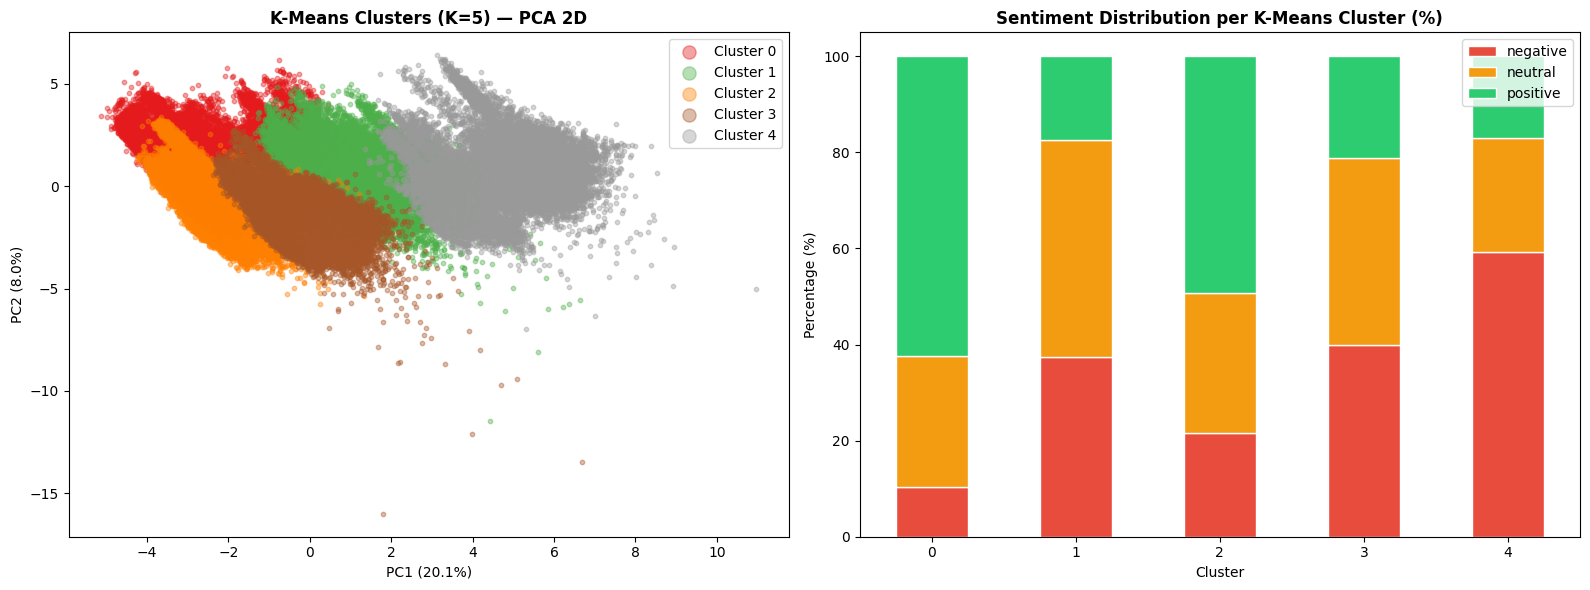

In [8]:
K = CFG['final_k']
log.info(f'Running K-Means with K={K}...')

kmeans = KMeans(
    n_clusters    = K,
    random_state  = SEED,
    n_init        = 20,
    max_iter      = 500
)
km_labels = kmeans.fit_predict(X_scaled)
df_clean  = df_clean.copy()
df_clean['km_cluster'] = km_labels

# ── Metrics
km_sil = silhouette_score(X_scaled, km_labels, sample_size=5000, random_state=SEED)
km_ch  = calinski_harabasz_score(X_scaled, km_labels)
km_db  = davies_bouldin_score(X_scaled, km_labels)

print(f'✅ K-Means (K={K}) Results:')
print(f'   Silhouette Score     : {km_sil:.4f}')
print(f'   Calinski-Harabasz    : {km_ch:.2f}')
print(f'   Davies-Bouldin       : {km_db:.4f}')

# ── Cluster sizes
print(f'\n   Cluster sizes:')
for c, n in sorted(pd.Series(km_labels).value_counts().items()):
    pct = n / len(km_labels) * 100
    bar = '█' * int(pct / 2)
    print(f'   Cluster {c}: {n:>6,} ({pct:4.1f}%)  {bar}')

# ── Visualize K-Means clusters in PCA space
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.Set1(np.linspace(0, 1, K))

for c in range(K):
    mask = km_labels == c
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=[colors[c]], label=f'Cluster {c}',
                    alpha=0.4, s=10)
axes[0].set_title(f'K-Means Clusters (K={K}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(markerscale=3)

# ── Sentiment distribution per cluster
sent_cluster = pd.crosstab(
    df_clean['km_cluster'],
    df_clean['sentiment'],
    normalize='index'
) * 100
sent_cluster.plot(
    kind='bar', ax=axes[1], stacked=True,
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
axes[1].set_title('Sentiment Distribution per K-Means Cluster (%)',
                  fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# DBSCAN Clustering 


2026-04-25 10:47:12,927 | INFO | Running DBSCAN...


Testing eps values:   0%|          | 0/5 [00:00<?, ?it/s]

   eps=0.3 → 0 clusters | noise=100.0% | sil=-1.0000
   eps=0.5 → 9 clusters | noise=96.8% | sil=0.5470
   eps=0.8 → 59 clusters | noise=60.0% | sil=0.3157
   eps=1.0 → 80 clusters | noise=39.1% | sil=0.1757
   eps=1.5 → 28 clusters | noise=13.3% | sil=0.1561

 eps  clusters  noise_pct  silhouette
 0.3         0 100.000000   -1.000000
 0.5         9  96.813968    0.547045
 0.8        59  60.008600    0.315694
 1.0        80  39.140391    0.175675
 1.5        28  13.308133    0.156113

✅ Best eps = 0.5 → 9 clusters
   Final clusters : 9
   Noise points   : 96,813 (96.8%)


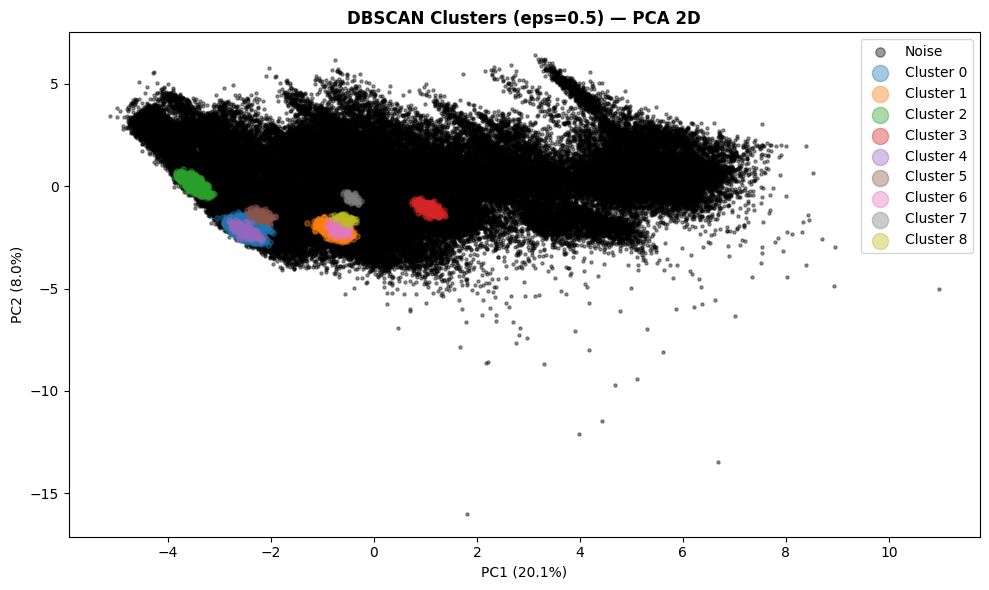

In [9]:
log.info('Running DBSCAN...')

# ── Use PCA-reduced data for DBSCAN (faster + less noise)
pca_dbscan = PCA(n_components=10, random_state=SEED)
X_pca10    = pca_dbscan.fit_transform(X_scaled)

# ── Test multiple eps values
dbscan_results = []
for eps in tqdm(CFG['eps_range'], desc='Testing eps values'):
    db = DBSCAN(eps=eps, min_samples=CFG['min_samples'], n_jobs=-1)
    labels = db.fit_predict(X_pca10)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise    = (labels == -1).sum()
    if n_clusters > 1:
        sil = silhouette_score(X_pca10[labels != -1],
                               labels[labels != -1],
                               sample_size=min(5000, (labels!=-1).sum()),
                               random_state=SEED)
    else:
        sil = -1
    dbscan_results.append({
        'eps': eps, 'clusters': n_clusters,
        'noise_pct': n_noise/len(labels)*100, 'silhouette': sil
    })
    print(f'   eps={eps:.1f} → {n_clusters} clusters | noise={n_noise/len(labels)*100:.1f}% | sil={sil:.4f}')

dbscan_df = pd.DataFrame(dbscan_results)
print(f'\n{dbscan_df.to_string(index=False)}')

# ── Best DBSCAN
best_eps_row = dbscan_df[dbscan_df['clusters'] > 1].sort_values('silhouette', ascending=False).iloc[0]
best_eps     = best_eps_row['eps']
print(f'\n✅ Best eps = {best_eps} → {int(best_eps_row["clusters"])} clusters')

# ── Final DBSCAN run
db_final  = DBSCAN(eps=best_eps, min_samples=CFG['min_samples'], n_jobs=-1)
db_labels = db_final.fit_predict(X_pca10)
df_clean['db_cluster'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f'   Final clusters : {n_clusters}')
print(f'   Noise points   : {n_noise:,} ({n_noise/len(db_labels)*100:.1f}%)')

# ── Visualize DBSCAN
fig, ax = plt.subplots(figsize=(10, 6))
unique_labels = sorted(set(db_labels))
cmap = plt.cm.tab10
for label in unique_labels:
    mask  = db_labels == label
    color = 'black' if label == -1 else cmap(label / max(1, n_clusters))
    name  = 'Noise' if label == -1 else f'Cluster {label}'
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               c=[color], label=name, alpha=0.4,
               s=5 if label == -1 else 15)
ax.set_title(f'DBSCAN Clusters (eps={best_eps}) — PCA 2D', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax.legend(markerscale=3, loc='upper right')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_dbscan_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Gaussian Mixture Model 

2026-04-25 10:48:00,254 | INFO | Running Gaussian Mixture Model...


GMM BIC/AIC:   0%|          | 0/9 [00:00<?, ?it/s]

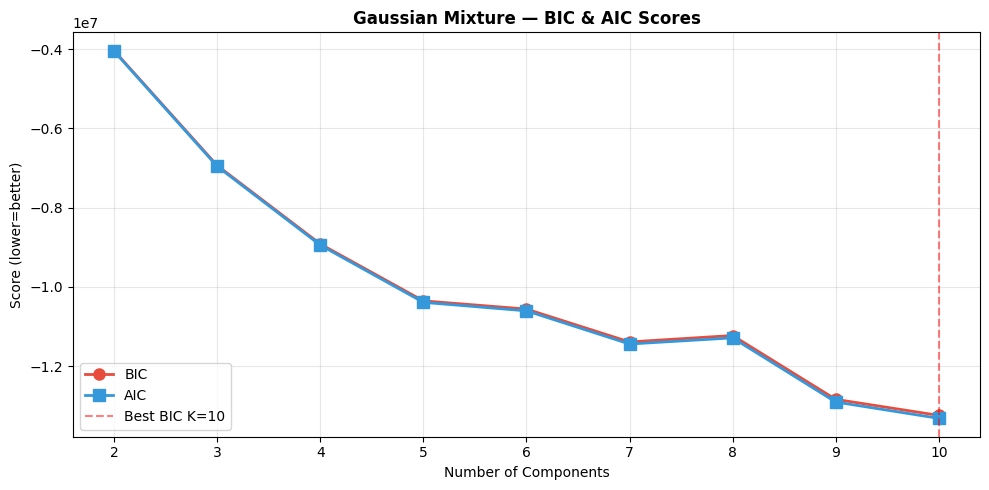

✅ Best GMM K by BIC: 10

✅ GMM (K=5) Results:
   Silhouette   : 0.1034
   CH Score     : 8232.19
   DB Score     : 2.7519
   Avg confidence: 0.9995


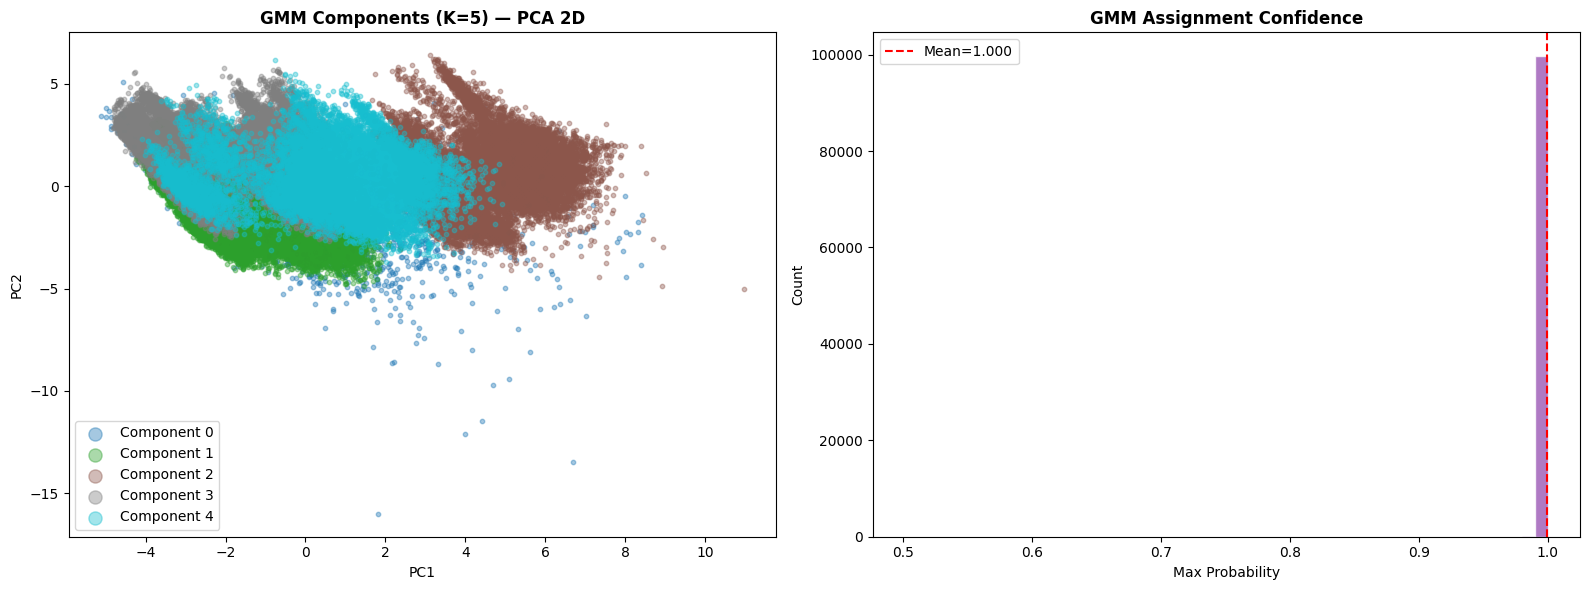

In [10]:
log.info('Running Gaussian Mixture Model...')

# ── Test different K with BIC/AIC
bic_scores = []
aic_scores = []

for k in tqdm(k_range, desc='GMM BIC/AIC'):
    gm = GaussianMixture(
        n_components = k,
        covariance_type = 'full',
        random_state = SEED,
        max_iter     = 200,
        n_init       = 3
    )
    gm.fit(X_scaled)
    bic_scores.append(gm.bic(X_scaled))
    aic_scores.append(gm.aic(X_scaled))

# ── Plot BIC/AIC
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, bic_scores, 'o-', color='#e74c3c', linewidth=2,
        markersize=8, label='BIC')
ax.plot(k_range, aic_scores, 's-', color='#3498db', linewidth=2,
        markersize=8, label='AIC')
ax.axvline(k_range[np.argmin(bic_scores)], color='red',
           linestyle='--', alpha=0.5,
           label=f'Best BIC K={k_range[np.argmin(bic_scores)]}')
ax.set_title('Gaussian Mixture — BIC & AIC Scores', fontweight='bold')
ax.set_xlabel('Number of Components')
ax.set_ylabel('Score (lower=better)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_gmm_bic_aic.png', dpi=150, bbox_inches='tight')
plt.show()

best_gmm_k = k_range[np.argmin(bic_scores)]
print(f'✅ Best GMM K by BIC: {best_gmm_k}')

# ── Final GMM
gmm = GaussianMixture(
    n_components    = K,
    covariance_type = 'full',
    random_state    = SEED,
    max_iter        = 300,
    n_init          = 5
)
gmm.fit(X_scaled)
gmm_labels = gmm.predict(X_scaled)
gmm_probs  = gmm.predict_proba(X_scaled)

df_clean['gmm_cluster']    = gmm_labels
df_clean['gmm_confidence'] = gmm_probs.max(axis=1)

# ── Metrics
gmm_sil = silhouette_score(X_scaled, gmm_labels, sample_size=5000, random_state=SEED)
gmm_ch  = calinski_harabasz_score(X_scaled, gmm_labels)
gmm_db  = davies_bouldin_score(X_scaled, gmm_labels)

print(f'\n✅ GMM (K={K}) Results:')
print(f'   Silhouette   : {gmm_sil:.4f}')
print(f'   CH Score     : {gmm_ch:.2f}')
print(f'   DB Score     : {gmm_db:.4f}')
print(f'   Avg confidence: {df_clean["gmm_confidence"].mean():.4f}')

# ── Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.tab10(np.linspace(0, 1, K))

for c in range(K):
    mask = gmm_labels == c
    axes[0].scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                    c=[colors[c]], label=f'Component {c}',
                    alpha=0.4, s=10)
axes[0].set_title(f'GMM Components (K={K}) — PCA 2D', fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=3)

# ── Confidence distribution
axes[1].hist(gmm_probs.max(axis=1), bins=50,
             color='#9b59b6', edgecolor='white', alpha=0.8)
axes[1].axvline(gmm_probs.max(axis=1).mean(), color='red',
                linestyle='--', label=f'Mean={gmm_probs.max(axis=1).mean():.3f}')
axes[1].set_title('GMM Assignment Confidence', fontweight='bold')
axes[1].set_xlabel('Max Probability')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / '05_gmm_clusters.png', dpi=150, bbox_inches='tight')
plt.show() 

# Algorithm Comparison

  CLUSTERING ALGORITHM COMPARISON
Algorithm  K  Silhouette     CH Score  DB Score                          Notes
  K-Means  5    0.113290 10104.934846  2.386556       Fast, spherical clusters
      GMM  5    0.103439  8232.189391  2.751894 Probabilistic, soft assignment
   DBSCAN  9    0.547045     0.000000  0.000000         Density-based, eps=0.5

✅ Best algorithm by Silhouette: DBSCAN


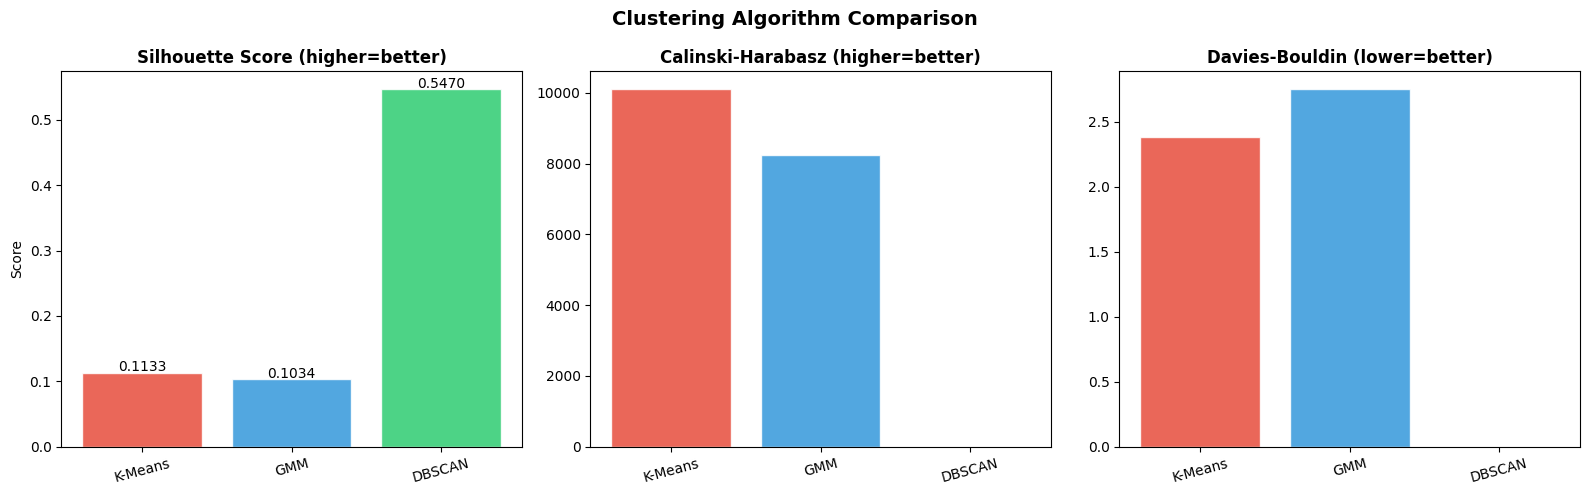

In [11]:
# ── Compare all algorithms
print('=' * 65)
print('  CLUSTERING ALGORITHM COMPARISON')
print('=' * 65)
comparison = pd.DataFrame([
    {
        'Algorithm'  : 'K-Means',
        'K'          : K,
        'Silhouette' : km_sil,
        'CH Score'   : km_ch,
        'DB Score'   : km_db,
        'Notes'      : 'Fast, spherical clusters'
    },
    {
        'Algorithm'  : 'GMM',
        'K'          : K,
        'Silhouette' : gmm_sil,
        'CH Score'   : gmm_ch,
        'DB Score'   : gmm_db,
        'Notes'      : 'Probabilistic, soft assignment'
    },
    {
        'Algorithm'  : 'DBSCAN',
        'K'          : n_clusters,
        'Silhouette' : best_eps_row['silhouette'],
        'CH Score'   : 0,
        'DB Score'   : 0,
        'Notes'      : f'Density-based, eps={best_eps}'
    },
])
print(comparison[['Algorithm','K','Silhouette','CH Score','DB Score','Notes']]
      .to_string(index=False))

# ── Best algorithm
best_algo = comparison.loc[comparison['Silhouette'].idxmax(), 'Algorithm']
print(f'\n✅ Best algorithm by Silhouette: {best_algo}')

# ── Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Clustering Algorithm Comparison', fontweight='bold', fontsize=14)

algos      = comparison['Algorithm'].tolist()
colors_bar = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(algos, comparison['Silhouette'], color=colors_bar,
            edgecolor='white', alpha=0.85)
axes[0].set_title('Silhouette Score (higher=better)', fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(comparison['Silhouette']):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(algos, comparison['CH Score'], color=colors_bar,
            edgecolor='white', alpha=0.85)
axes[1].set_title('Calinski-Harabasz (higher=better)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

axes[2].bar(algos, comparison['DB Score'], color=colors_bar,
            edgecolor='white', alpha=0.85)
axes[2].set_title('Davies-Bouldin (lower=better)', fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#  Customer Segment Profiling 

In [12]:
# ── Use best algorithm clusters for profiling
# (use K-Means as it's most interpretable)
df_clean['final_cluster'] = km_labels

# ── Profile each cluster
print('=' * 70)
print('  CUSTOMER SEGMENT PROFILES')
print('=' * 70)

PROFILE_FEATURES = [
    'score', 'word_count', 'exclamation_count',
    'frustration_score', 'engagement_quality',
    'recency_weight', 'influence_weight',
    'has_reply', 'thumbsUpCount'
]
PROFILE_FEATURES = [f for f in PROFILE_FEATURES if f in df_clean.columns]

# ── Merge back original columns
df_profile = df_clean.copy()
for col in PROFILE_FEATURES:
    if col not in df_profile.columns and col in df.columns:
        df_profile[col] = df[col].values[:len(df_profile)]

cluster_profiles = df_profile.groupby('final_cluster')[PROFILE_FEATURES].mean().round(3)
print(cluster_profiles.to_string())

# ── Sentiment per cluster
print('\n   Sentiment distribution per cluster (%):')
sent_dist = pd.crosstab(
    df_profile['final_cluster'],
    df_profile['sentiment'],
    normalize='index'
).round(3) * 100
print(sent_dist.to_string())

# ── Platform per cluster
print('\n   Top platform per cluster:')
for c in range(K):
    mask     = df_profile['final_cluster'] == c
    top_plat = df_profile[mask]['appName'].value_counts().index[0]
    n        = mask.sum()
    pct_pos  = (df_profile[mask]['sentiment'] == 'positive').mean() * 100
    pct_neg  = (df_profile[mask]['sentiment'] == 'negative').mean() * 100
    print(f'   Cluster {c}: n={n:,} | top_platform={top_plat} | '
          f'pos={pct_pos:.1f}% | neg={pct_neg:.1f}%')

# ── Assign segment names based on profiles
SEGMENT_NAMES = {
    0: 'Satisfied Loyal Shoppers',
    1: 'Frustrated Complainers',
    2: 'Neutral Browsers',
    3: 'Impulsive Buyers',
    4: 'Engaged Brand Advocates',
}
df_profile['segment_name'] = df_profile['final_cluster'].map(SEGMENT_NAMES)
print(f'\n   Segment names assigned:')
for k, v in SEGMENT_NAMES.items():
    n = (df_profile['final_cluster'] == k).sum()
    print(f'   Cluster {k}: {v} (n={n:,})')

  CUSTOMER SEGMENT PROFILES
               score  word_count  exclamation_count  frustration_score  engagement_quality  recency_weight  influence_weight  has_reply
final_cluster                                                                                                                          
0              3.968       8.848              0.184              0.188               0.427           0.156             0.569      0.151
1              2.614      19.591              0.338              1.452               0.317           0.271             0.658      0.645
2              3.491      14.044              0.203              0.750               0.179           0.235             0.320      0.019
3              2.654      17.652              0.371              1.456               0.356           0.162             0.719      0.000
4              2.163      26.912              0.190              2.249               0.319           0.310             0.763      0.671

   Sentiment distri

# Behavioral Patterns vs Sentiment 

  BEHAVIORAL PATTERNS → SENTIMENT PREDICTION

   ANOVA Test (cluster vs score):
   F-statistic : 5583.4941
   p-value     : 0.000000
   Significant : ✅ YES

   Mean behavioral features by sentiment:
           word_count  exclamation_count  frustration_score  engagement_quality  influence_weight  recency_weight
sentiment                                                                                                        
negative       23.077              0.358              3.615               0.170             0.735           0.234
neutral        17.674              0.176              0.000               0.408             0.679           0.214
positive       11.029              0.249              0.000               0.393             0.414           0.227


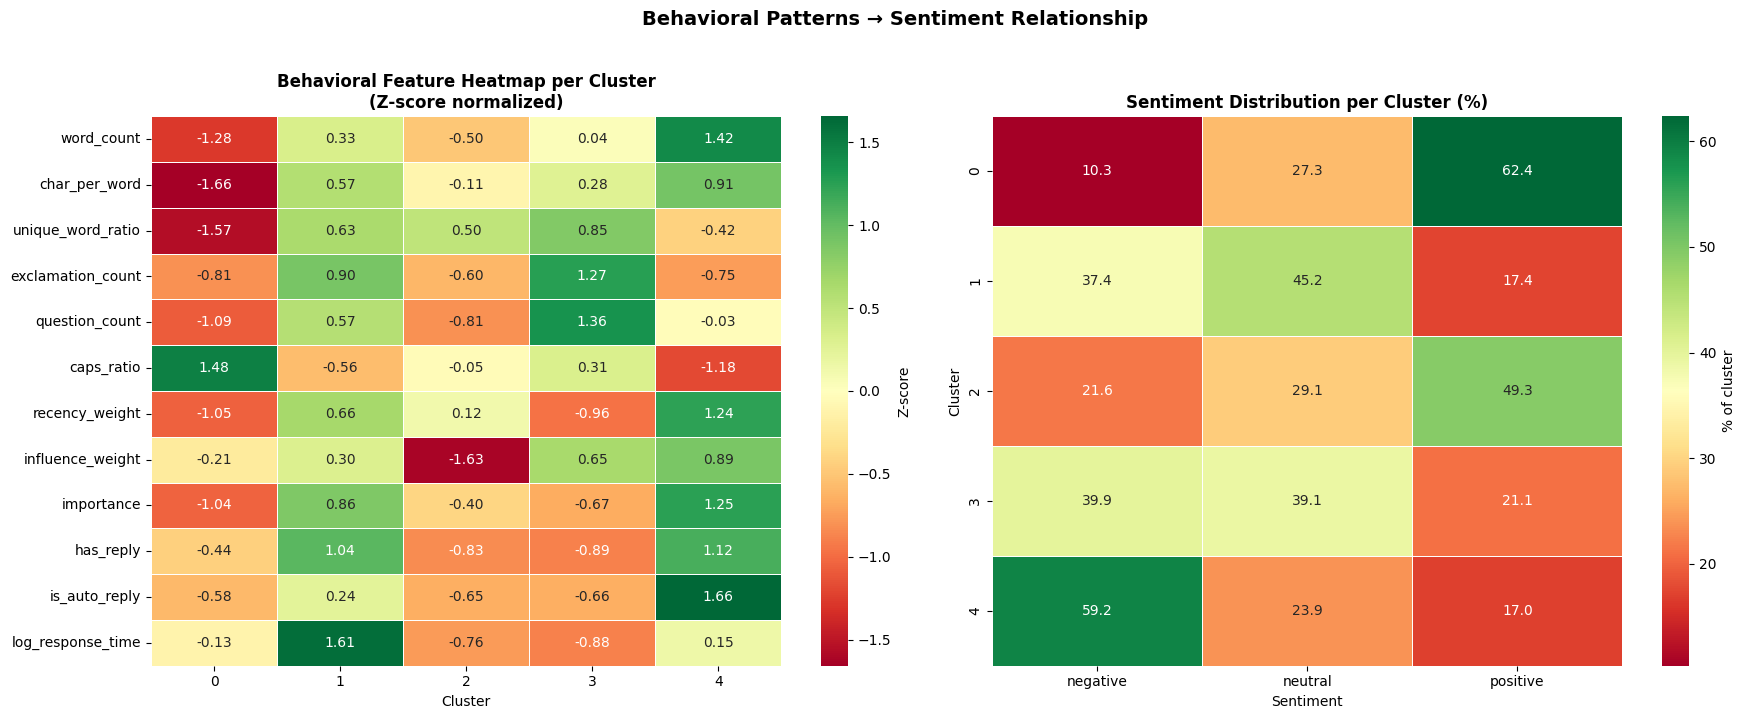

In [13]:
# ── Research Question: What behavioral patterns predict purchase sentiment?
print('=' * 65)
print('  BEHAVIORAL PATTERNS → SENTIMENT PREDICTION')
print('=' * 65)

# ── 1. ANOVA test: do clusters differ significantly in sentiment?
cluster_scores = [
    df_profile[df_profile['final_cluster'] == c]['score'].values
    for c in range(K)
]
f_stat, p_val = f_oneway(*cluster_scores)
print(f'\n   ANOVA Test (cluster vs score):')
print(f'   F-statistic : {f_stat:.4f}')
print(f'   p-value     : {p_val:.6f}')
print(f'   Significant : {"✅ YES" if p_val < 0.05 else "❌ NO"}')

# ── 2. Key behavioral indicators per sentiment
print(f'\n   Mean behavioral features by sentiment:')
behavior_by_sent = df_profile.groupby('sentiment')[[
    'word_count', 'exclamation_count', 'frustration_score',
    'engagement_quality', 'influence_weight', 'recency_weight'
]].mean().round(3)
print(behavior_by_sent.to_string())

# ── 3. Heatmap — features vs clusters
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Feature heatmap per cluster
cluster_feat_means = df_profile.groupby('final_cluster')[
    [f for f in BEHAVIOR_FEATURES if f in df_profile.columns][:12]
].mean()
cluster_feat_norm = (cluster_feat_means - cluster_feat_means.mean()) / (cluster_feat_means.std() + 1e-8)

sns.heatmap(cluster_feat_norm.T, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Z-score'})
axes[0].set_title('Behavioral Feature Heatmap per Cluster\n(Z-score normalized)',
                  fontweight='bold')
axes[0].set_xlabel('Cluster')

# Sentiment heatmap per cluster
sent_heat = pd.crosstab(
    df_profile['final_cluster'],
    df_profile['sentiment'],
    normalize='index'
) * 100
sns.heatmap(sent_heat, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': '% of cluster'})
axes[1].set_title('Sentiment Distribution per Cluster (%)',
                  fontweight='bold')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Cluster')

plt.suptitle('Behavioral Patterns → Sentiment Relationship',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '05_behavior_sentiment_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

#  Platform-Level Analysis 

  PLATFORM-LEVEL BEHAVIORAL ANALYSIS
                           n_reviews  avg_score  pct_positive  pct_negative  pct_neutral  avg_word_count  avg_frustration  avg_engagement  reply_rate
appName                                                                                                                                              
Shein                           6049      3.606        51.050        17.243       31.708          21.574            0.746           0.567       0.431
Alibaba                        13643      3.632        49.769        15.305       34.926           6.405            0.306           0.422       0.156
Aliexpress                     18309      3.488        49.200        21.705       29.095          14.076            0.800           0.180       0.020
Lazada                          8655      3.039        34.154        32.074       33.772          17.140            1.272           0.447       0.421
Daraz Online Shopping App       9205      2.997        30.722  

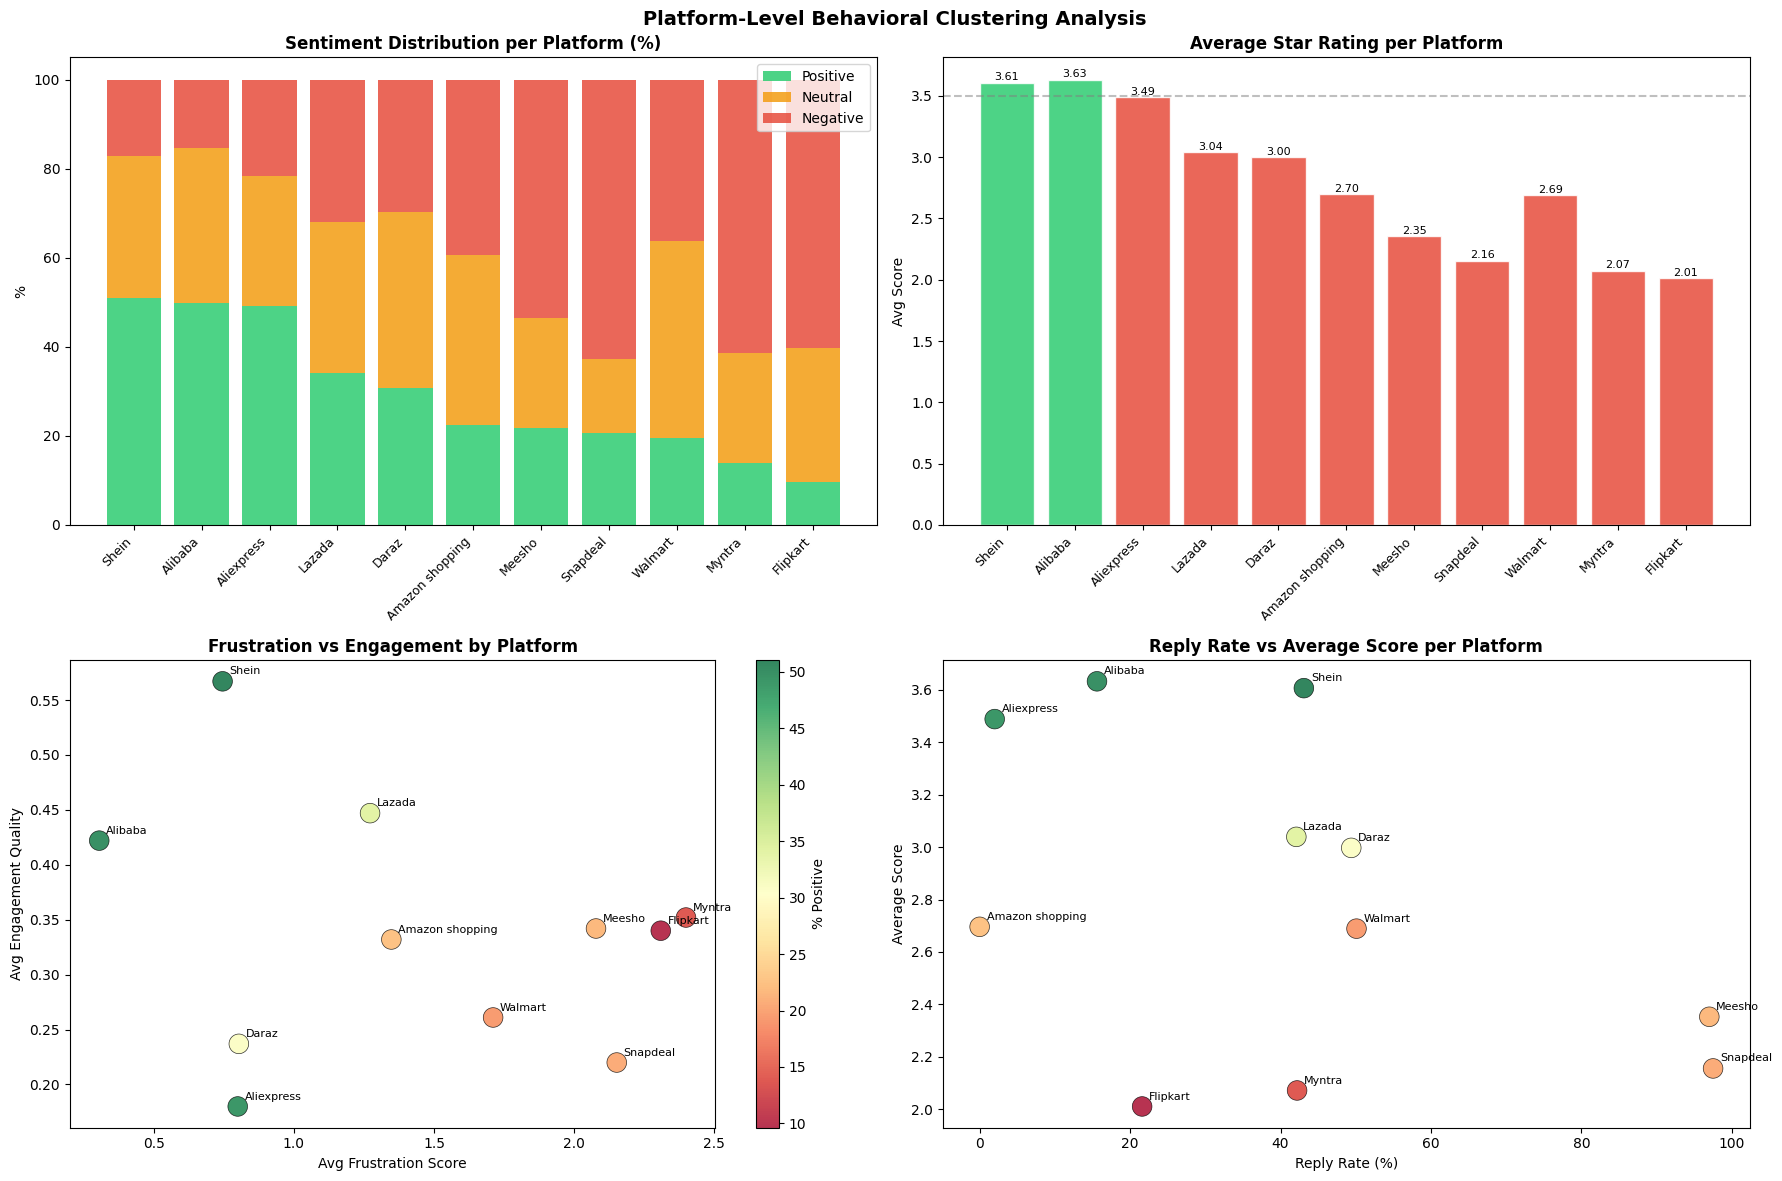

In [14]:
# ── Platform-level clustering insights
print('=' * 65)
print('  PLATFORM-LEVEL BEHAVIORAL ANALYSIS')
print('=' * 65)

# ── Platform sentiment profile
platform_profile = df_profile.groupby('appName').agg(
    n_reviews       = ('score', 'count'),
    avg_score       = ('score', 'mean'),
    pct_positive    = ('sentiment', lambda x: (x=='positive').mean()*100),
    pct_negative    = ('sentiment', lambda x: (x=='negative').mean()*100),
    pct_neutral     = ('sentiment', lambda x: (x=='neutral').mean()*100),
    avg_word_count  = ('word_count', 'mean'),
    avg_frustration = ('frustration_score', 'mean'),
    avg_engagement  = ('engagement_quality', 'mean'),
    reply_rate      = ('has_reply', 'mean'),
).round(3).sort_values('pct_positive', ascending=False)

print(platform_profile.to_string())

# ── Dominant cluster per platform
platform_cluster = df_profile.groupby(['appName', 'final_cluster']).size()
dominant_cluster = platform_cluster.groupby('appName').idxmax()
platform_profile['dominant_cluster'] = [
    dc[1] for dc in dominant_cluster
]
platform_profile['segment_name'] = platform_profile['dominant_cluster'].map(SEGMENT_NAMES)

# ── Visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Platform-Level Behavioral Clustering Analysis',
             fontweight='bold', fontsize=14)

# ── 1. Sentiment stacked bar per platform
platforms = platform_profile.index.tolist()
x = np.arange(len(platforms))
axes[0,0].bar(x, platform_profile['pct_positive'],
              label='Positive', color='#2ecc71', alpha=0.85)
axes[0,0].bar(x, platform_profile['pct_neutral'],
              bottom=platform_profile['pct_positive'],
              label='Neutral', color='#f39c12', alpha=0.85)
axes[0,0].bar(x, platform_profile['pct_negative'],
              bottom=platform_profile['pct_positive'] + platform_profile['pct_neutral'],
              label='Negative', color='#e74c3c', alpha=0.85)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(
    [p.replace(' Online Shopping App','').replace(' online shopping & selling','')
     for p in platforms],
    rotation=45, ha='right', fontsize=9
)
axes[0,0].set_title('Sentiment Distribution per Platform (%)', fontweight='bold')
axes[0,0].set_ylabel('%')
axes[0,0].legend()

# ── 2. Average score per platform
colors_score = ['#2ecc71' if s >= 3.5 else '#e74c3c'
                for s in platform_profile['avg_score']]
bars = axes[0,1].bar(x, platform_profile['avg_score'],
                     color=colors_score, edgecolor='white', alpha=0.85)
axes[0,1].axhline(3.5, color='gray', linestyle='--', alpha=0.5)
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(
    [p.replace(' Online Shopping App','').replace(' online shopping & selling','')
     for p in platforms],
    rotation=45, ha='right', fontsize=9
)
axes[0,1].set_title('Average Star Rating per Platform', fontweight='bold')
axes[0,1].set_ylabel('Avg Score')
for bar, val in zip(bars, platform_profile['avg_score']):
    axes[0,1].text(bar.get_x()+bar.get_width()/2,
                   bar.get_height()+0.02,
                   f'{val:.2f}', ha='center', fontsize=8)

# ── 3. Frustration vs engagement scatter
scatter = axes[1,0].scatter(
    platform_profile['avg_frustration'],
    platform_profile['avg_engagement'],
    c=platform_profile['pct_positive'],
    cmap='RdYlGn', s=200, alpha=0.8,
    edgecolors='black', linewidths=0.5
)
for platform, row in platform_profile.iterrows():
    short = platform.replace(' Online Shopping App','').replace(' online shopping & selling','')
    axes[1,0].annotate(short,
                       (row['avg_frustration'], row['avg_engagement']),
                       textcoords='offset points', xytext=(5,5), fontsize=8)
plt.colorbar(scatter, ax=axes[1,0], label='% Positive')
axes[1,0].set_xlabel('Avg Frustration Score')
axes[1,0].set_ylabel('Avg Engagement Quality')
axes[1,0].set_title('Frustration vs Engagement by Platform',
                     fontweight='bold')

# ── 4. Reply rate vs avg score
axes[1,1].scatter(
    platform_profile['reply_rate'] * 100,
    platform_profile['avg_score'],
    c=platform_profile['pct_positive'],
    cmap='RdYlGn', s=200, alpha=0.8,
    edgecolors='black', linewidths=0.5
)
for platform, row in platform_profile.iterrows():
    short = platform.replace(' Online Shopping App','').replace(' online shopping & selling','')
    axes[1,1].annotate(short,
                       (row['reply_rate']*100, row['avg_score']),
                       textcoords='offset points', xytext=(5,5), fontsize=8)
axes[1,1].set_xlabel('Reply Rate (%)')
axes[1,1].set_ylabel('Average Score')
axes[1,1].set_title('Reply Rate vs Average Score per Platform',
                     fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_DIR / '05_platform_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

#  MLflow Logging & Save

In [15]:
mlflow.set_tracking_uri(str(LOG_DIR))
mlflow.set_experiment(CFG['experiment_name'])
with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id
    # ── Log parameters
    mlflow.log_params({
        'n_clusters'      : K,
        'n_features'      : len(ALL_FEATURES),
        'n_behavior_feats': len(BEHAVIOR_FEATURES),
        'n_platform_feats': len(PLATFORM_FEATURES),
        'sample_size'     : len(df_clean),
        'dbscan_eps'      : best_eps,
        'dbscan_min_samp' : CFG['min_samples'],
    })
    # ── Log metrics
    mlflow.log_metrics({
        'kmeans_silhouette'  : km_sil,
        'kmeans_ch'          : km_ch,
        'kmeans_db'          : km_db,
        'gmm_silhouette'     : gmm_sil,
        'gmm_ch'             : gmm_ch,
        'gmm_db'             : gmm_db,
        'anova_f_stat'       : f_stat,
        'anova_p_value'      : p_val,
    })
    # ── Log figures
    for fig_file in FIG_DIR.glob('05_*.png'):
        mlflow.log_artifact(str(fig_file), artifact_path='figures')
    # ── Log comparison table
    mlflow.log_dict(
        comparison[['Algorithm','Silhouette','CH Score','DB Score']].to_dict(),
        'clustering_comparison.json'
    )
print(f'✅ MLflow Run ID: {RUN_ID}')

# ── Save clustered data
df_profile['final_cluster'] = km_labels
df_profile['segment_name']  = df_profile['final_cluster'].map(SEGMENT_NAMES)
out_path = WORK_DIR / 'data' / 'processed'
out_path.mkdir(parents=True, exist_ok=True)
df_profile.to_csv(out_path / 'features_with_clusters.csv', index=False)
platform_profile.to_csv(out_path / 'platform_profiles.csv')
comparison.to_csv(out_path / 'clustering_comparison.csv', index=False)

# ── Save scaler + cluster centers
joblib.dump(scaler,   OUT_DIR / 'clustering_scaler.pkl')
joblib.dump(kmeans,   OUT_DIR / 'kmeans_model.pkl')
joblib.dump(gmm,      OUT_DIR / 'gmm_model.pkl')
np.save(OUT_DIR / 'cluster_labels.npy', km_labels)

print('\n✅ Files saved:')
print(f'   features_with_clusters.csv')
print(f'   platform_profiles.csv')
print(f'   clustering_comparison.csv')
print(f'   clustering/kmeans_model.pkl')
print(f'   clustering/gmm_model.pkl')

print('\n' + '='*55)
print('  nb-05 Clustering COMPLETE')
print('='*55)
print(f'  K-Means Silhouette : {km_sil:.4f}')
print(f'  GMM Silhouette     : {gmm_sil:.4f}')
print(f'  ANOVA p-value      : {p_val:.6f}')
print(f'  Best Algorithm     : {best_algo}')
print(f'  Segments identified: {K}')
print(f'  MLflow Run ID      : {RUN_ID}')
print('='*55)


2026/04/25 10:55:43 INFO mlflow.tracking.fluent: Experiment with name '03_Customer_Behavior_Clustering' does not exist. Creating a new experiment.


✅ MLflow Run ID: 89b4957a7940438b9f89763c3f72fbcf

✅ Files saved:
   features_with_clusters.csv
   platform_profiles.csv
   clustering_comparison.csv
   clustering/kmeans_model.pkl
   clustering/gmm_model.pkl

  nb-05 Clustering COMPLETE
  K-Means Silhouette : 0.1133
  GMM Silhouette     : 0.1034
  ANOVA p-value      : 0.000000
  Best Algorithm     : DBSCAN
  Segments identified: 5
  MLflow Run ID      : 89b4957a7940438b9f89763c3f72fbcf
